# Skyrmions under an applied field gradient

In [1]:
import fidimag
from fidimag.micro import Sim
from fidimag.common import CuboidMesh
from fidimag.micro import Zeeman, Demag, DMI, UniformExchange
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


Here we set parameters of the system. We choose a 250 x 80 x 3 nm nanotrack, and apply periodicity in the x-direction to approximate an infinite nanotrack.

In [2]:
dx = dy = 2.5
dz = 1.0


Lx = 250.0
Ly = 80.0
Lz = 3.0
nx = int(Lx/dx)
ny = int(Ly/dy)
nz = int(Lz/dz)

mesh = CuboidMesh(nx=nx, ny=ny, nz=nz, dx=dx, dy=dy, dz=dz,
                  unit_length=1e-9, periodicity=(True, False, False))

We choose material parameters for Fe0.7Co0.3Si as used in the paper "Skyrmions in thin films with easy-plane magnetocrystalline anisotropy" (http://dx.doi.org/10.1063/1.4945262). We set the initial state to be uniform in the +z direction.

In [3]:
Ms = 9.5e4  # magnetisation saturation (A/m)
A = 4e-13  # exchange stiffness (J/m)
D = 2.7e-4  # DMI constant (J/m**2)
H = (0, 0, 3.8e5)  # external magnetic field (A/m)

K0 = D**2 / A
K1 = -0.16*K0

alpha = 0.5  # Gilbert damping
gamma = 2.211e5  # gyromagnetic ratio (m/As)

sim  = Sim(mesh)  # create simulation object

# Set parameters.
sim.Ms = Ms
sim.driver.alpha = alpha
sim.driver.gamma = gamma
sim.driver.do_precession = False

# Add energies.
sim.add(UniformExchange(A=A))
sim.add(DMI(D))
sim.add(Zeeman(H))
sim.add(Demag(pbc_2d=True))
# Seed random number generator so that this simulation is reproducible.
np.random.seed(0)

def m_init(pos):
    m = np.random.uniform(-1, 1, 3)
    return m

sim.set_m(m_init, normalise=True)

We now relax the system to find a metastable state.

In [4]:
sim.driver.relax(dt=1e-13, stopping_dmdt=0.1, max_steps=5000, save_m_steps=None, save_vtk_steps=None)

#1    t=1e-13    dt=1e-13 max_dmdt=7.78e+04
#2    t=2e-13    dt=1e-13 max_dmdt=7.99e+04
#3    t=3e-13    dt=1e-13 max_dmdt=8.01e+04
#4    t=4e-13    dt=1e-13 max_dmdt=7.76e+04
#5    t=5e-13    dt=1e-13 max_dmdt=7.97e+04
#6    t=6e-13    dt=1e-13 max_dmdt=7.75e+04
#7    t=7e-13    dt=1e-13 max_dmdt=7.6e+04
#8    t=8e-13    dt=1e-13 max_dmdt=7.94e+04
#9    t=9e-13    dt=1e-13 max_dmdt=8.26e+04
#10   t=1e-12    dt=1e-13 max_dmdt=8.09e+04
#11   t=1.1e-12  dt=1e-13 max_dmdt=7.42e+04
#12   t=1.2e-12  dt=1e-13 max_dmdt=7.66e+04
#13   t=1.3e-12  dt=1e-13 max_dmdt=7.76e+04
#14   t=1.4e-12  dt=1e-13 max_dmdt=7.47e+04
#15   t=1.5e-12  dt=1e-13 max_dmdt=7.08e+04
#16   t=1.6e-12  dt=1e-13 max_dmdt=6.4e+04
#17   t=1.7e-12  dt=1e-13 max_dmdt=6.47e+04
#18   t=1.8e-12  dt=1e-13 max_dmdt=6.4e+04


#19   t=1.9e-12  dt=1e-13 max_dmdt=6.21e+04
#20   t=2e-12    dt=1e-13 max_dmdt=6.02e+04
#21   t=2.1e-12  dt=1e-13 max_dmdt=5.71e+04
#22   t=2.2e-12  dt=1e-13 max_dmdt=5.63e+04
#23   t=2.3e-12  dt=1e-13 max_dmdt=5.47e+04
#24   t=2.4e-12  dt=1e-13 max_dmdt=5.24e+04
#25   t=2.5e-12  dt=1e-13 max_dmdt=5.1e+04
#26   t=2.6e-12  dt=1e-13 max_dmdt=5.1e+04
#27   t=2.7e-12  dt=1e-13 max_dmdt=5.02e+04
#28   t=2.8e-12  dt=1e-13 max_dmdt=4.86e+04
#29   t=2.9e-12  dt=1e-13 max_dmdt=4.64e+04
#30   t=3e-12    dt=1e-13 max_dmdt=4.37e+04
#31   t=3.1e-12  dt=1e-13 max_dmdt=4.24e+04
#32   t=3.2e-12  dt=1e-13 max_dmdt=4.19e+04
#33   t=3.3e-12  dt=1e-13 max_dmdt=4.09e+04
#34   t=3.4e-12  dt=1e-13 max_dmdt=3.95e+04
#35   t=3.5e-12  dt=1e-13 max_dmdt=3.92e+04
#36   t=3.6e-12  dt=1e-13 max_dmdt=3.92e+04
#37   t=3.7e-12  dt=1e-13 max_dmdt=3.95e+04
#38   t=3.8e-12  dt=1e-13 max_dmdt=4.03e+04
#39   t=3.9e-12  dt=1e-13 max_dmdt=4.05e+04
#40   t=4e-12    dt=1e-13 max_dmdt=4.08e+04
#41   t=4.1e-12  dt=1e-13 max_dmdt

#45   t=4.5e-12  dt=1e-13 max_dmdt=4.06e+04
#46   t=4.6e-12  dt=1e-13 max_dmdt=4e+04
#47   t=4.7e-12  dt=1e-13 max_dmdt=3.93e+04
#48   t=4.8e-12  dt=1e-13 max_dmdt=3.85e+04
#49   t=4.9e-12  dt=1e-13 max_dmdt=3.76e+04
#50   t=5e-12    dt=1e-13 max_dmdt=3.66e+04
#51   t=5.1e-12  dt=1e-13 max_dmdt=3.55e+04
#52   t=5.2e-12  dt=1e-13 max_dmdt=3.43e+04
#53   t=5.3e-12  dt=1e-13 max_dmdt=3.32e+04
#54   t=5.4e-12  dt=1e-13 max_dmdt=3.23e+04
#55   t=5.5e-12  dt=1e-13 max_dmdt=3.19e+04
#56   t=5.6e-12  dt=1e-13 max_dmdt=3.21e+04
#57   t=5.7e-12  dt=1e-13 max_dmdt=3.23e+04
#58   t=5.8e-12  dt=1e-13 max_dmdt=3.26e+04
#59   t=5.9e-12  dt=1e-13 max_dmdt=3.29e+04
#60   t=6e-12    dt=1e-13 max_dmdt=3.31e+04
#61   t=6.1e-12  dt=1e-13 max_dmdt=3.32e+04
#62   t=6.2e-12  dt=1e-13 max_dmdt=3.31e+04
#63   t=6.3e-12  dt=1e-13 max_dmdt=3.3e+04
#64   t=6.4e-12  dt=1e-13 max_dmdt=3.27e+04
#65   t=6.5e-12  dt=1e-13 max_dmdt=3.23e+04
#66   t=6.6e-12  dt=1e-13 max_dmdt=3.18e+04
#67   t=6.7e-12  dt=1e-13 max_dmdt=3

#83   t=8.35e-12 dt=1.27e-13 max_dmdt=2.86e+04
#84   t=8.48e-12 dt=1.27e-13 max_dmdt=2.78e+04
#85   t=8.61e-12 dt=1.27e-13 max_dmdt=2.68e+04
#86   t=8.73e-12 dt=1.27e-13 max_dmdt=2.6e+04
#87   t=8.86e-12 dt=1.27e-13 max_dmdt=2.64e+04
#88   t=8.99e-12 dt=1.27e-13 max_dmdt=2.66e+04
#89   t=9.11e-12 dt=1.27e-13 max_dmdt=2.67e+04
#90   t=9.24e-12 dt=1.27e-13 max_dmdt=2.67e+04
#91   t=9.37e-12 dt=1.27e-13 max_dmdt=2.65e+04
#92   t=9.49e-12 dt=1.27e-13 max_dmdt=2.63e+04
#93   t=9.62e-12 dt=1.27e-13 max_dmdt=2.6e+04
#94   t=9.75e-12 dt=1.27e-13 max_dmdt=2.55e+04
#95   t=9.88e-12 dt=1.27e-13 max_dmdt=2.51e+04
#96   t=1e-11    dt=1.27e-13 max_dmdt=2.45e+04
#97   t=1.01e-11 dt=1.27e-13 max_dmdt=2.44e+04
#98   t=1.03e-11 dt=1.27e-13 max_dmdt=2.43e+04
#99   t=1.04e-11 dt=1.27e-13 max_dmdt=2.4e+04
#100  t=1.05e-11 dt=1.27e-13 max_dmdt=2.37e+04
#101  t=1.06e-11 dt=1.27e-13 max_dmdt=2.33e+04
#102  t=1.08e-11 dt=1.27e-13 max_dmdt=2.29e+04
#103  t=1.09e-11 dt=1.27e-13 max_dmdt=2.24e+04
#104  t=1.1e-11 

#113  t=1.22e-11 dt=1.27e-13 max_dmdt=1.89e+04
#114  t=1.23e-11 dt=1.27e-13 max_dmdt=1.86e+04
#115  t=1.24e-11 dt=1.27e-13 max_dmdt=1.85e+04
#116  t=1.25e-11 dt=1.27e-13 max_dmdt=1.92e+04
#117  t=1.27e-11 dt=1.27e-13 max_dmdt=1.99e+04
#118  t=1.28e-11 dt=1.27e-13 max_dmdt=2.05e+04
#119  t=1.29e-11 dt=1.27e-13 max_dmdt=2.1e+04
#120  t=1.3e-11  dt=1.27e-13 max_dmdt=2.15e+04
#121  t=1.32e-11 dt=1.27e-13 max_dmdt=2.19e+04
#122  t=1.33e-11 dt=1.27e-13 max_dmdt=2.23e+04
#123  t=1.34e-11 dt=1.27e-13 max_dmdt=2.25e+04
#124  t=1.36e-11 dt=1.27e-13 max_dmdt=2.27e+04
#125  t=1.37e-11 dt=1.27e-13 max_dmdt=2.28e+04
#126  t=1.38e-11 dt=1.27e-13 max_dmdt=2.28e+04
#127  t=1.39e-11 dt=1.27e-13 max_dmdt=2.28e+04
#128  t=1.41e-11 dt=1.27e-13 max_dmdt=2.27e+04
#129  t=1.42e-11 dt=1.27e-13 max_dmdt=2.24e+04
#130  t=1.43e-11 dt=1.27e-13 max_dmdt=2.22e+04
#131  t=1.44e-11 dt=1.27e-13 max_dmdt=2.18e+04
#132  t=1.46e-11 dt=1.27e-13 max_dmdt=2.14e+04
#133  t=1.47e-11 dt=1.27e-13 max_dmdt=2.1e+04
#134  t=1.48e-1

...

#1151 t=5.09e-08 dt=6.44e-10 max_dmdt=0.386
#1152 t=5.16e-08 dt=6.44e-10 max_dmdt=0.349


#1153 t=5.22e-08 dt=6.44e-10 max_dmdt=0.315
#1154 t=5.29e-08 dt=6.44e-10 max_dmdt=0.284
#1155 t=5.35e-08 dt=6.44e-10 max_dmdt=0.256


#1156 t=5.42e-08 dt=6.44e-10 max_dmdt=0.231
#1157 t=5.48e-08 dt=6.44e-10 max_dmdt=0.209
#1158 t=5.55e-08 dt=6.44e-10 max_dmdt=0.188


#1159 t=5.61e-08 dt=6.44e-10 max_dmdt=0.17
#1160 t=5.67e-08 dt=6.44e-10 max_dmdt=0.153
#1161 t=5.74e-08 dt=6.44e-10 max_dmdt=0.138
#1162 t=5.8e-08  dt=6.44e-10 max_dmdt=0.125


#1163 t=5.87e-08 dt=6.44e-10 max_dmdt=0.112
#1164 t=5.93e-08 dt=6.44e-10 max_dmdt=0.101
#1165 t=6.03e-08 dt=9.85e-10 max_dmdt=0.0889


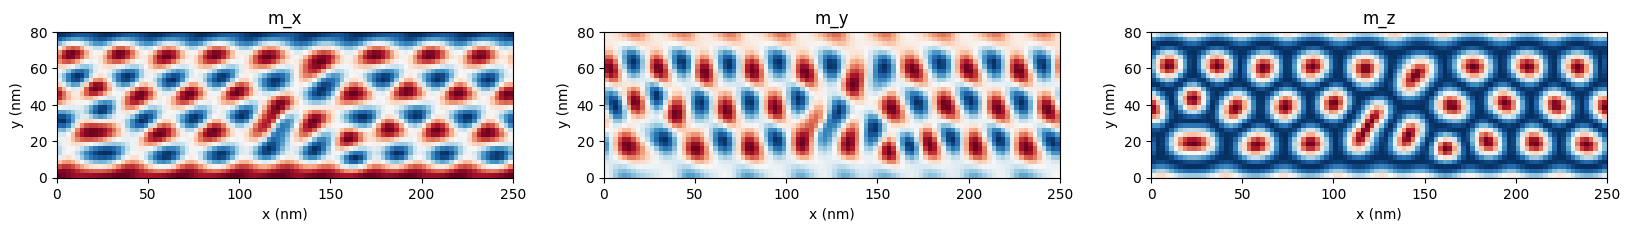

In [5]:
def plot_field(field, sim, fieldname, layer=0):
    nx = sim.mesh.nx
    ny = sim.mesh.ny
    n_layer = sim.mesh.nx * sim.mesh.ny
    m = field.reshape(-1, 3)
    
    fx = m[:, 0][layer*n_layer:(layer+1)*n_layer]
    fy = m[:, 1][layer*n_layer:(layer+1)*n_layer]
    fz = m[:, 2][layer*n_layer:(layer+1)*n_layer]
    fx.shape = (ny, nx)
    fy.shape = (ny, nx)
    fz.shape = (ny, nx)
    
    extent = [0, nx*sim.mesh.dx, 0, ny*sim.mesh.dy]
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 3, 1)
    plt.imshow(fx, extent=extent, cmap='RdBu', origin='lower')
    plt.title('{}_x'.format(fieldname))
    plt.xlabel('x (nm)')
    plt.ylabel('y (nm)')
    plt.subplot(1, 3, 2)
    plt.imshow(fy, extent=extent, cmap='RdBu', origin='lower')
    plt.xlabel('x (nm)')
    plt.ylabel('y (nm)')
    plt.title('{}_y'.format(fieldname))
    plt.subplot(1, 3, 3)
    plt.imshow(fz, extent=extent, cmap='RdBu', origin='lower')
    plt.xlabel('x (nm)')
    plt.ylabel('y (nm)')
    plt.title('{}_z'.format(fieldname))
    
plot_field(sim.spin, sim, 'm')

We now apply a field gradient which acts to move the Skyrmions. Below we construct a function to impose this gradient, and just plot the resulting Zeeman field.

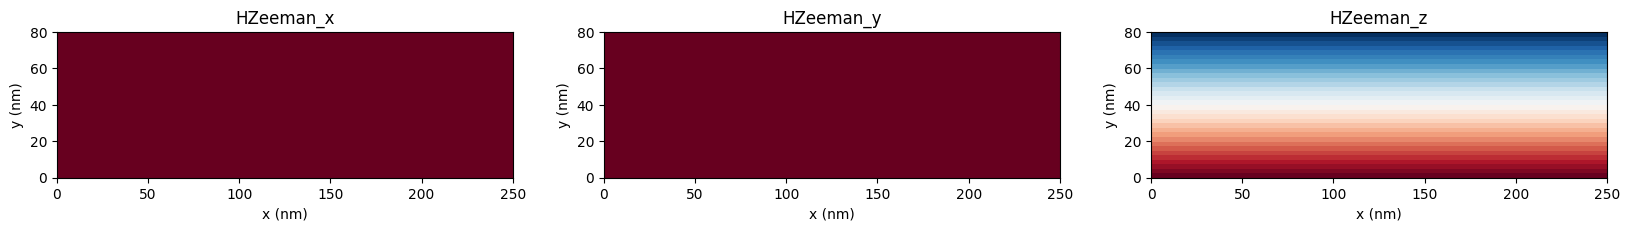

In [6]:
H0 = 0.3 / (4*np.pi*1e-7) # Apply a field of 0.4T

def H_Gradient(pos):
    x, y, z = pos
    return (0, 0, H0 * y/Ly)

zee = Zeeman(H_Gradient)
sim.add(zee)
plot_field(zee.field, sim, 'HZeeman')

We now evolve in time, showing snapshots of the magnetisation every 1ns.

i = 0, t = 0.0ns
i = 1, t = 1e-09ns


i = 2, t = 2e-09ns


i = 3, t = 3.0000000000000004e-09ns


i = 4, t = 4e-09ns


i = 5, t = 5e-09ns


...

i = 16, t = 1.6e-08ns


i = 17, t = 1.7e-08ns


i = 18, t = 1.8000000000000002e-08ns


i = 19, t = 1.9e-08ns
i = 20, t = 2e-08ns


/tmp/ipykernel_767011/123838774.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20, 10))


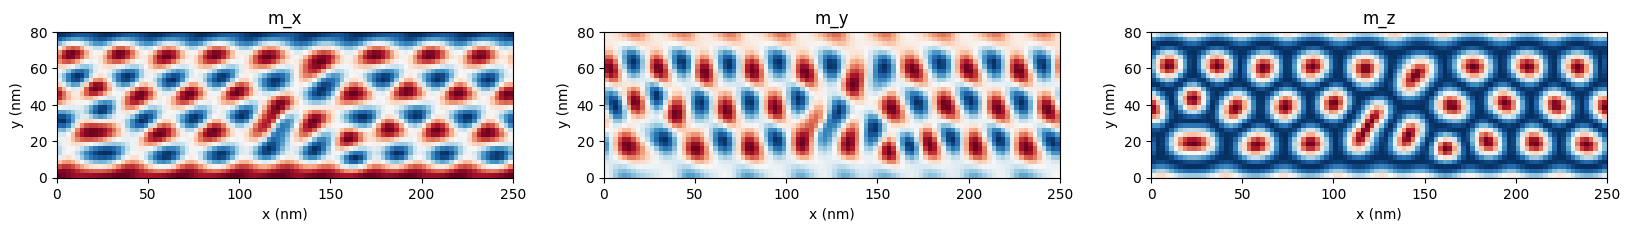

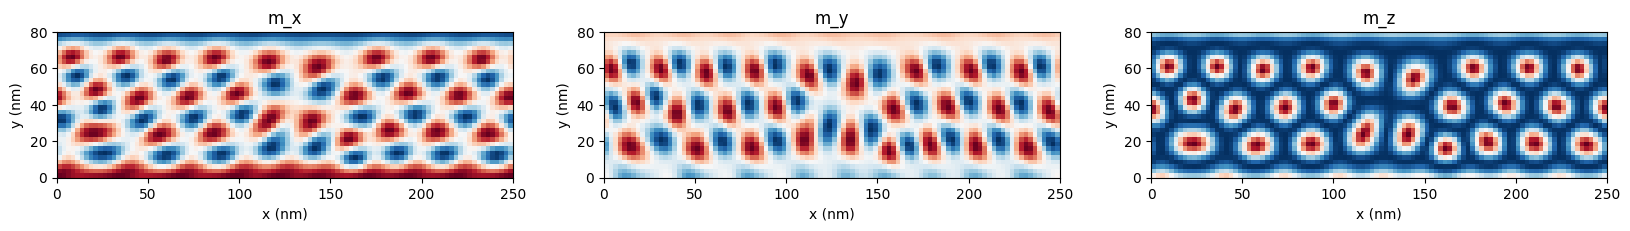

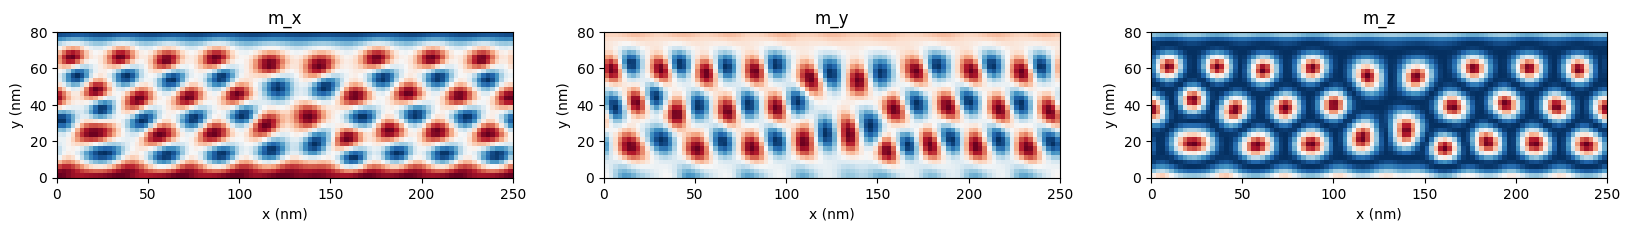

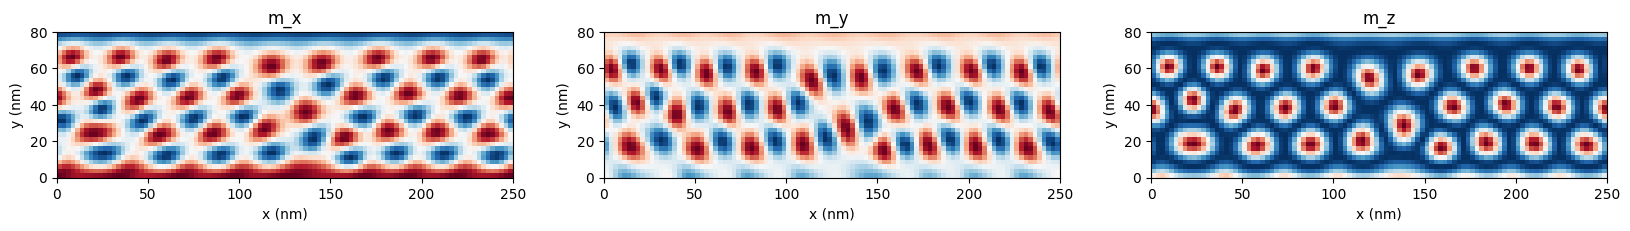

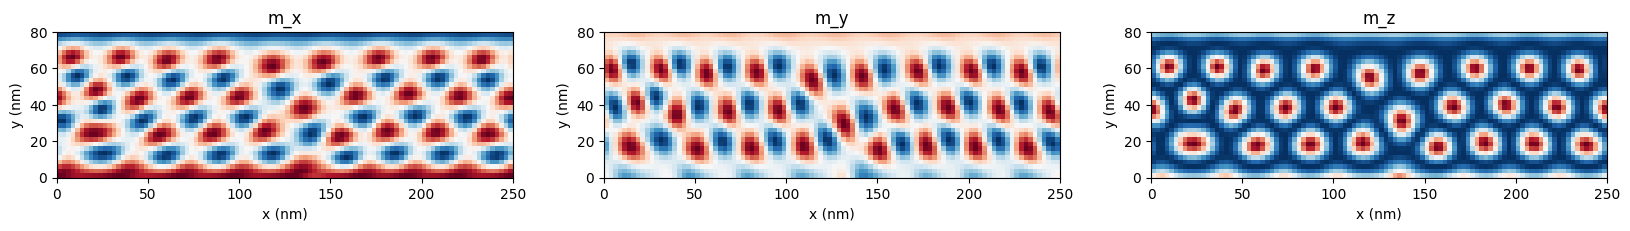

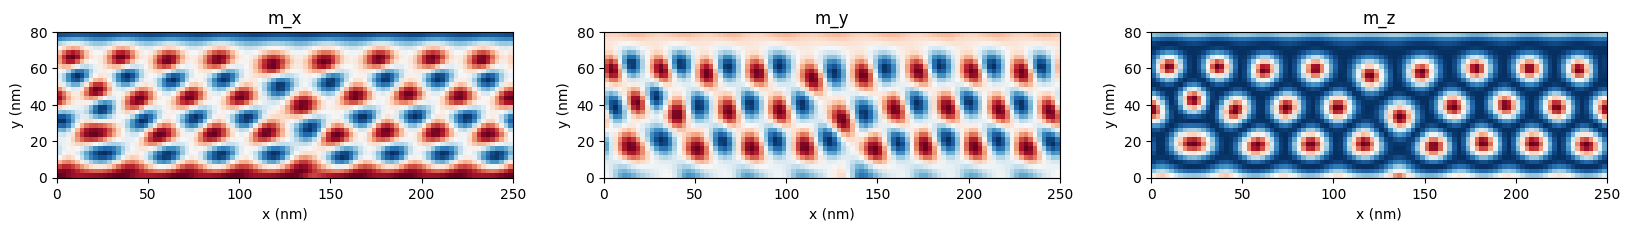

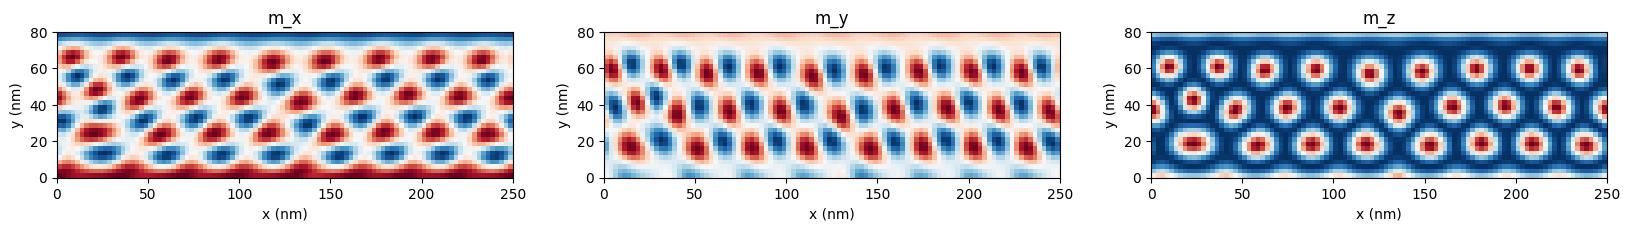

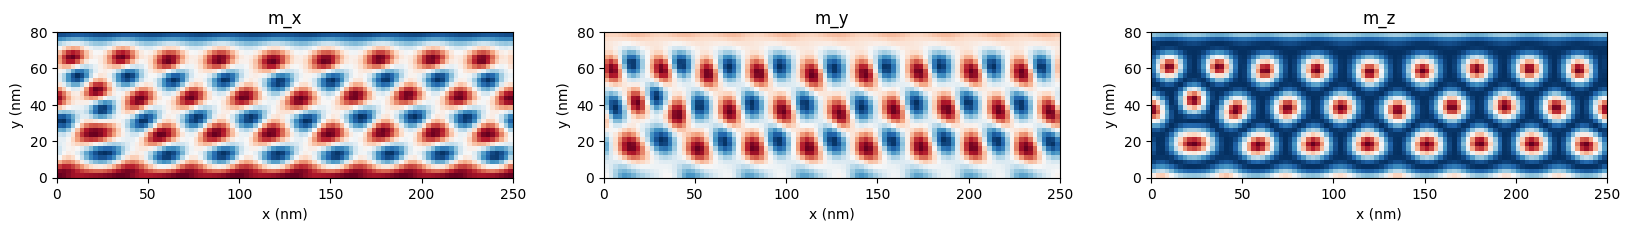

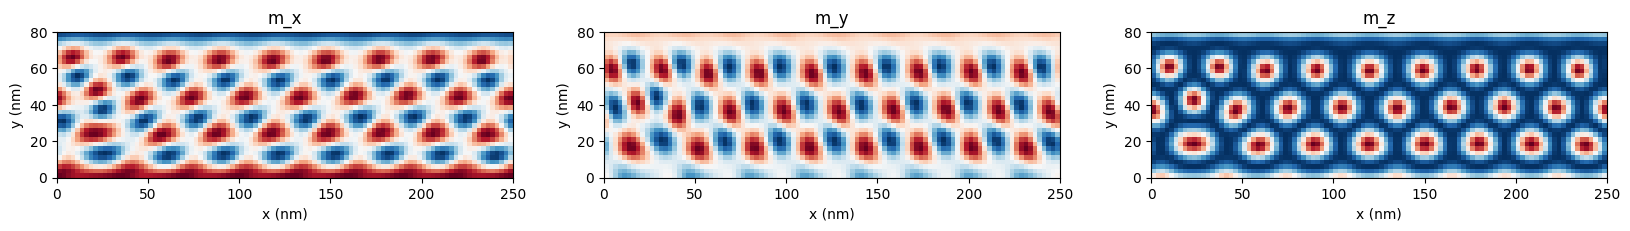

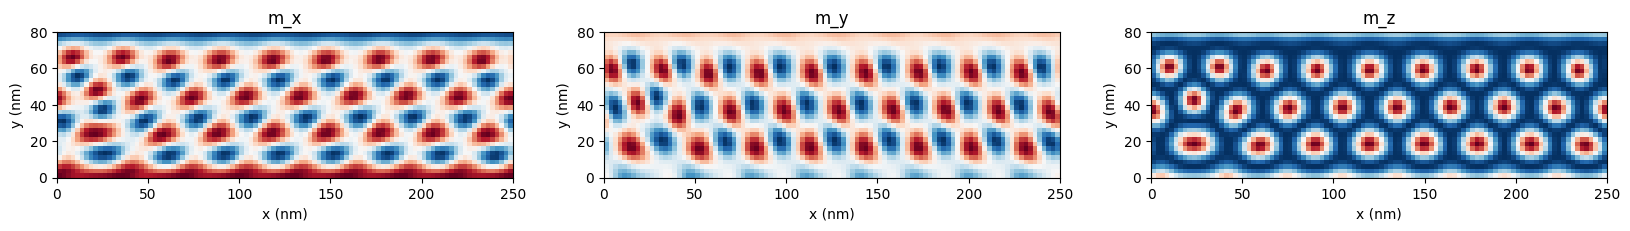

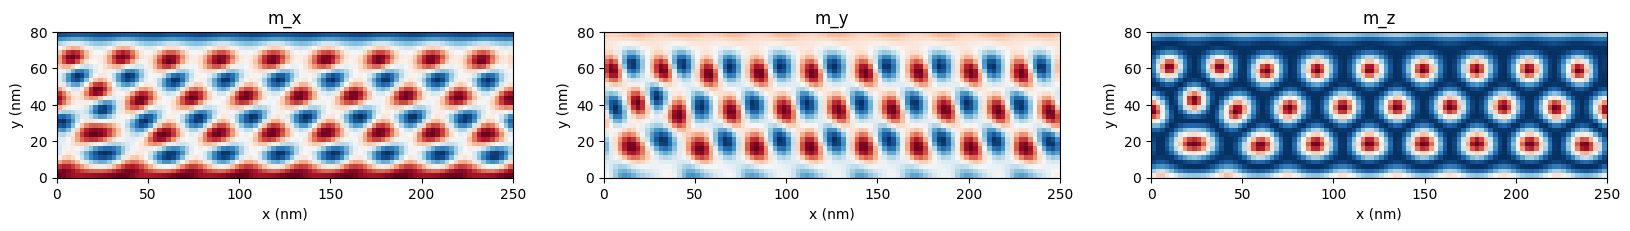

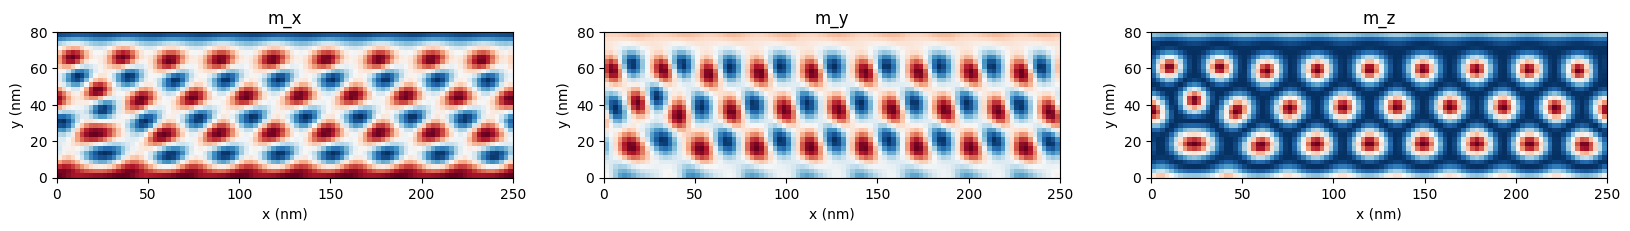

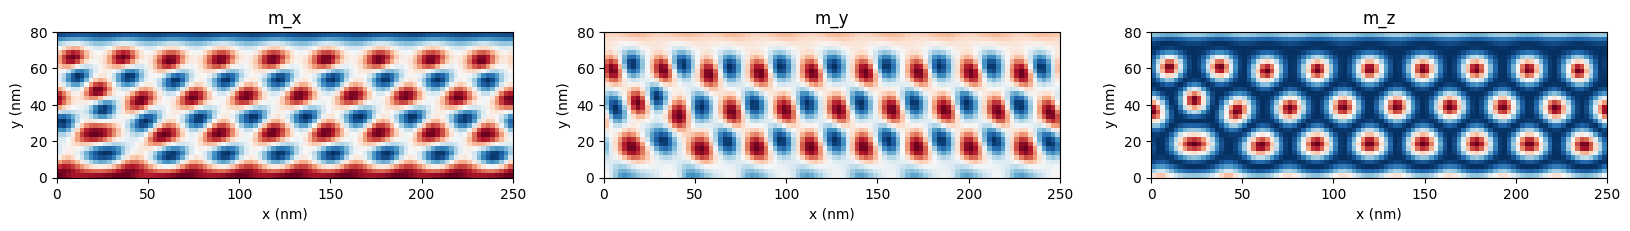

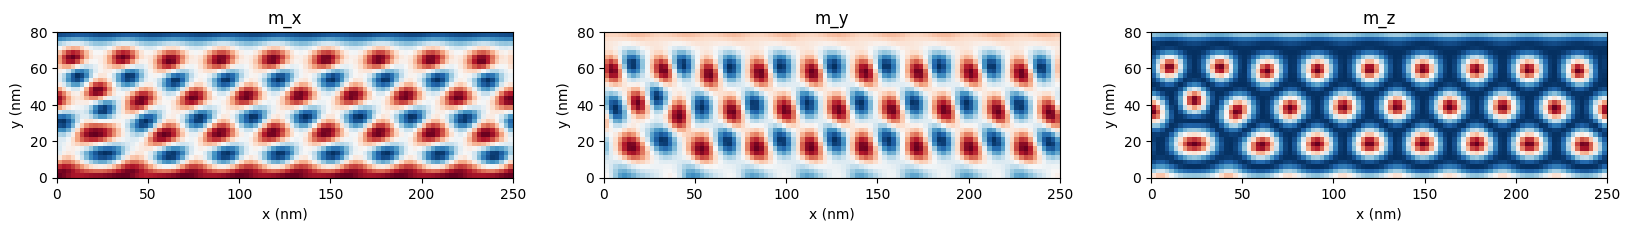

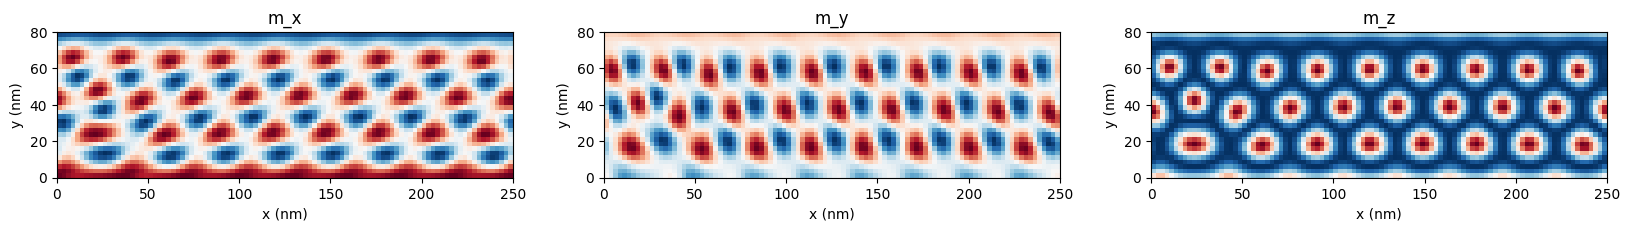

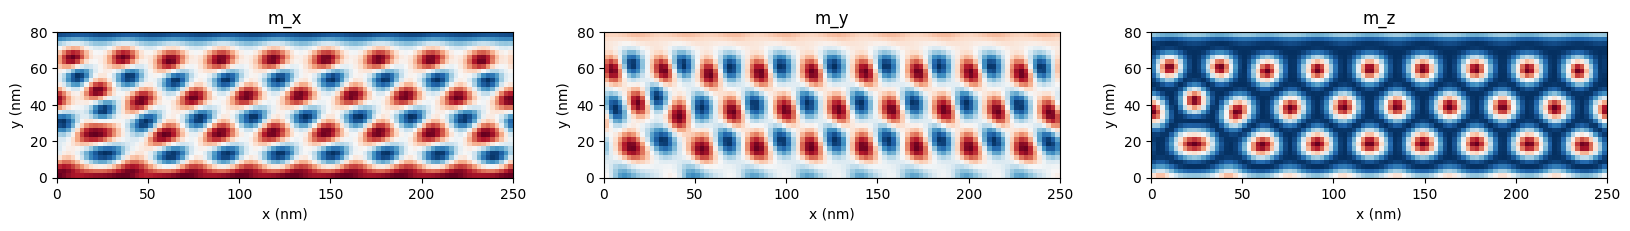

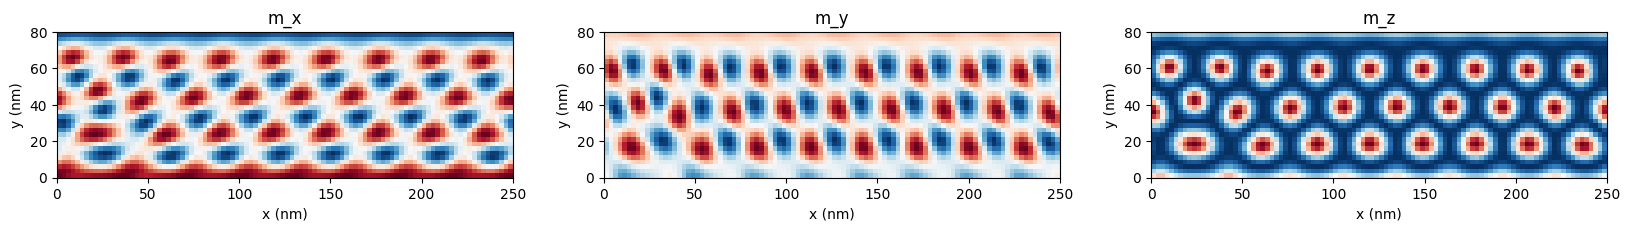

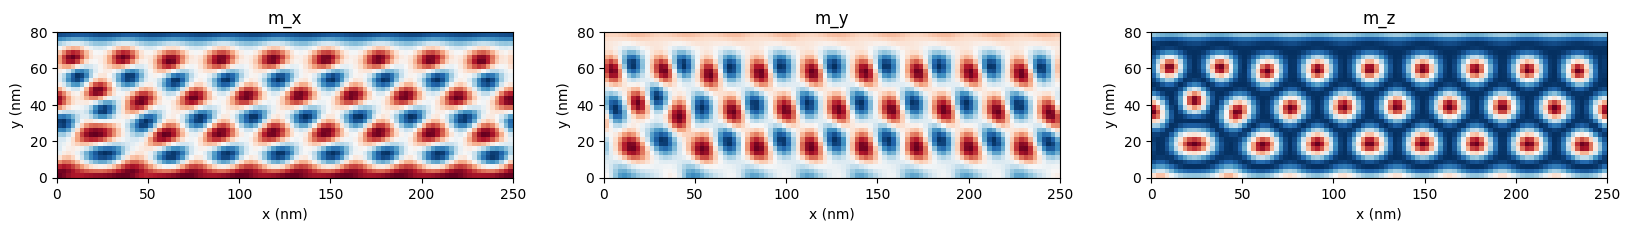

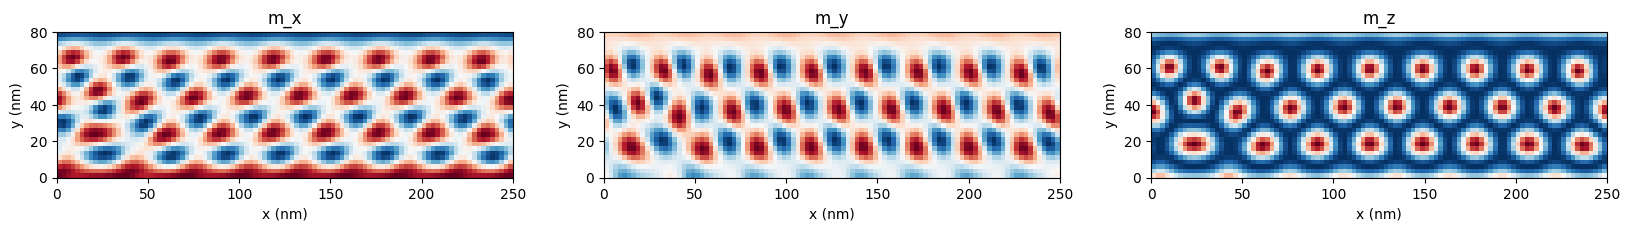

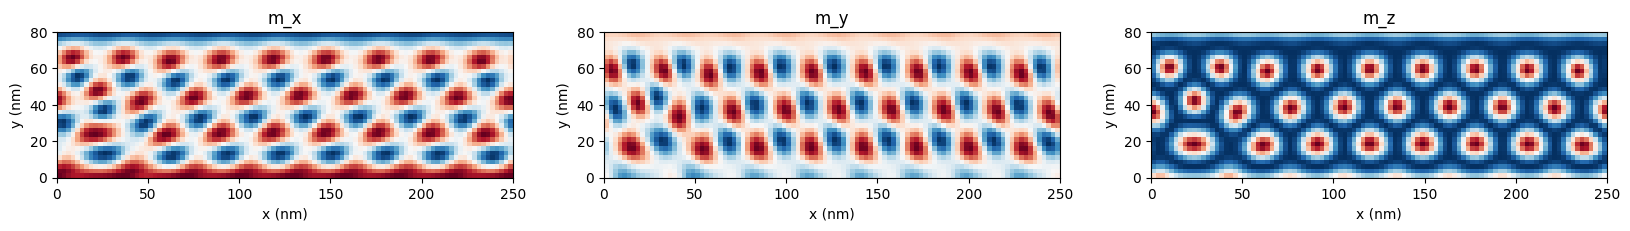

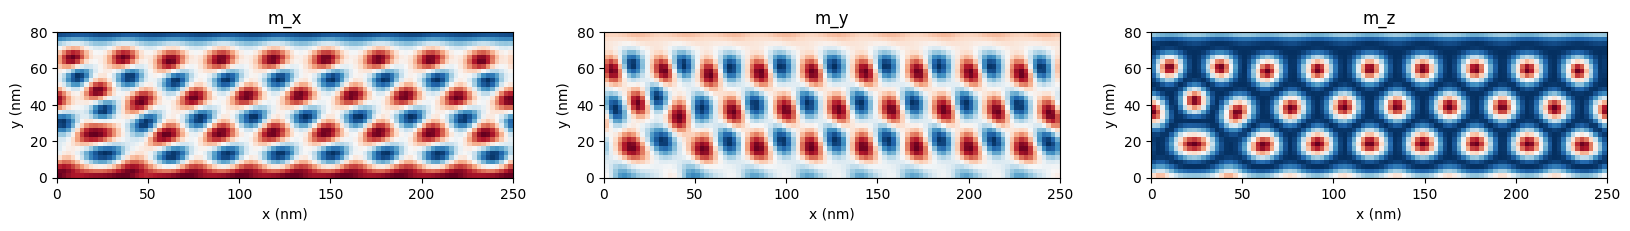

In [7]:
sim.driver.reset_integrator()
for i, t in enumerate(np.linspace(0, 20e-9, 21)):
    print('i = {}, t = {}ns'.format(i, t))
    sim.driver.run_until(t)
    plot_field(sim.spin, sim, 'm')


We can see that the core of the Skyrmions in the high-field region is smaller than than in the low field region, and there is some motion away from this area boundary.

We can also plot particular fields:

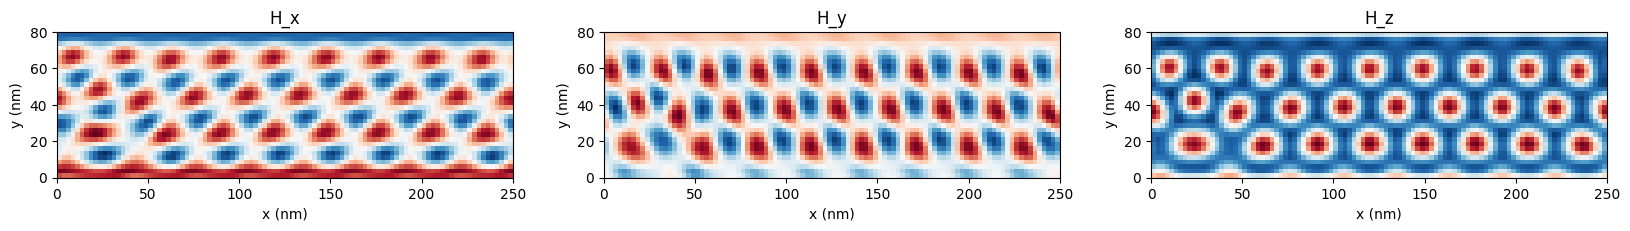

In [8]:
# Plot the Effective Field
plot_field(sim.driver.field, sim, 'H')

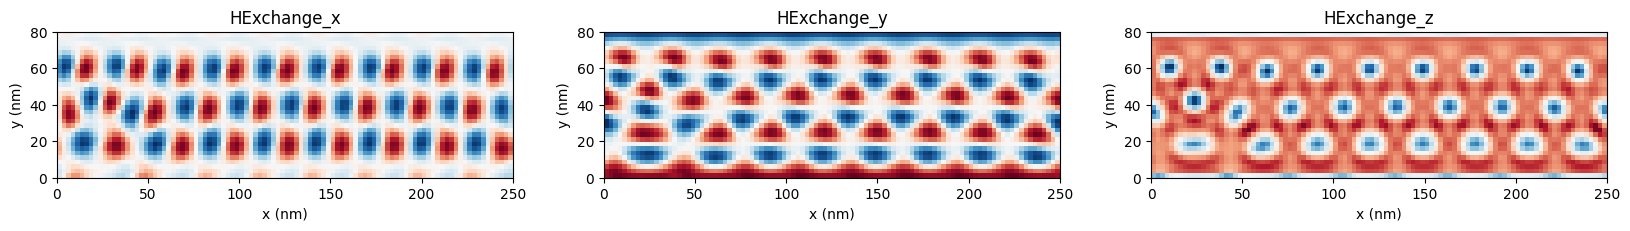

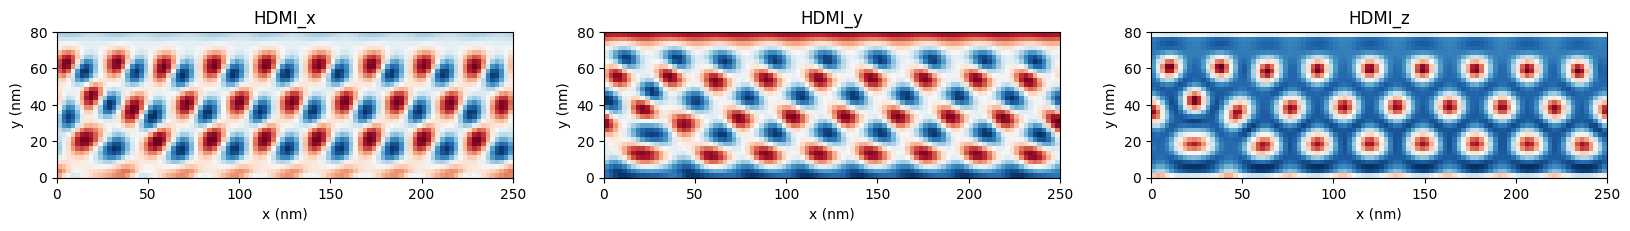

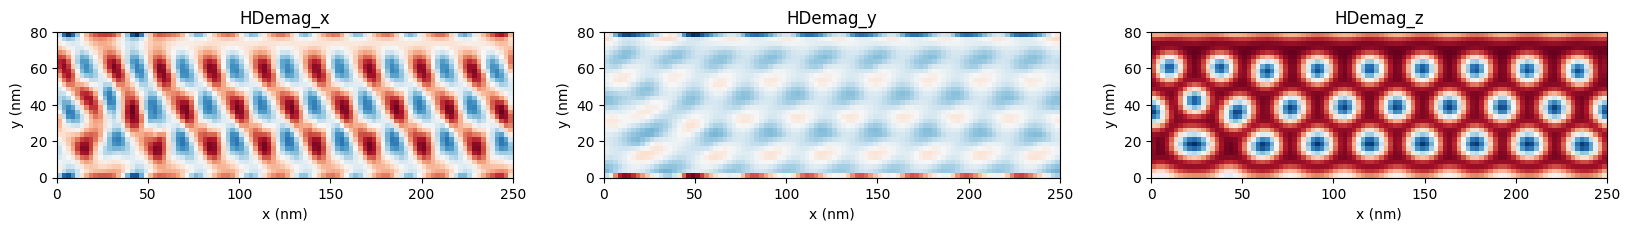

In [9]:
plot_field(sim.get_interaction('UniformExchange').field, sim, 'HExchange')

plot_field(sim.get_interaction('DMI').field, sim, 'HDMI')

plot_field(sim.get_interaction('Demag').field, sim, 'HDemag')